# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [3]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users =pd.read_csv('/datasets/users_latam.csv') #completa el código
usage =pd.read_csv('/datasets/usage.csv') #completa el código

In [5]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [6]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [7]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [8]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [9]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [11]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [12]:
# cantidad de nulos para users
print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [13]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
*- ¿Qué columnas tienen valores faltantes y en qué proporción?*
- city tiene 469 nulos que equivalen al 11%
- churn_date que tiene 3534 nulos equivalentes al 88%
- date: 50 faltantes menos del 1 %
- duration: 22076 equivalente al 55%
- lenght 17896 44%
  
*- Indica qué harías: ¿imputar, eliminar, ignorar?*
- City:Investigar sobre este dato.
- churn_date ignorar o eliminar esta information
- date:imputacion o dejar nulo
- duration/ lenght ignorar o eliminar    

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [14]:
# explorar columnas numéricas de users
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


- La columna `user_id` y `age` "Estas columnas no presentan valores nulos y tienen tipos de datos apropiados."s (int64)
- `reg_date` debe ser tipo datetime
- `churn_date` 466 valores no nulos indican clientes que cancelaron el servicio. Los valores nulos (3534) representan clientes activos. Requiere conversión a tipo datetime.

In [15]:
# explorar columnas numéricas de usage
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


- Las columnas `id` y `user_id` "Estas columnas no presentan valores nulos y tienen tipos de datos apropiados."s (int64)
- La columnas `date` tiene 39950 nulos y debe ser modificada a tipo datetime para el analisis
- La columna `duration` tiene 17924 nulos y `lenght` tambien 

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` tiene 3531 entradas, 7 unicas y la ciudad mas repetida es Bogota con una frecuencia de 808
- La columna `plan` tiene 4000 entradas con 2 planes unicos siendo el Basico el preferido con 2595 entradas

In [17]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` nos da 40000 entradas 2 unicas siendo texto el mas usado con 22092 entradas


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- 1. churn_date = NaN/null
- Sentinel: Valores nulos
- Significado: Cliente activo (no ha cancelado)
- Cantidad: 3534 registros

2. city = valores faltantes
- Sentinel: Valores nulos  
- Significado: Ciudad no registrada o error en captura
- Cantidad: 469 registros faltantes (4000-3531)

3. date = NaN/null
- Sentinel: Valores nulos
- Significado: ¿Registros sin fecha válida? ¿Datos de prueba?
- Cantidad: 39950 registros

4. duration y length = NaN/null
- Sentinel: Valores nulos
- Significado: ¿Llamadas no completadas? ¿Tipos de uso sin duración?
  
**- ¿Qué acción tomarías?  **
- Churn_date siento que es un valor que se podria dejar o confirmar si es correcto ya que eso son los clientes que ha cancelado su servicio
- city revisar que tanta indicencia tiene en el analisis la falta de estos datos
- date altos valores faltantes se debe investigar

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =pd.to_datetime(users['reg_date'],errors='coerce',utc= True) # completa el código

In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors='coerce',utc= True)# completa el código

In [20]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].describe()

count                          4000
unique                         3961
top       2026-05-10 00:00:00+00:00
freq                             40
first     2022-01-01 00:00:00+00:00
last      2026-05-10 00:00:00+00:00
Name: reg_date, dtype: object

En `reg_date`
Total de registros: 4,000 entradas
Registros con datos válidos: 3,961 (99.02%)
Registros faltantes: 39 (0.98%)
Fecha más antigua: 2022
Fecha más reciente: 2026
Problema fechas futuras identificadas: 

In [21]:
# Revisar los años presentes en `date` de usage
usage['date'].describe()

count                                   39950
unique                                  39950
top       2024-05-22 03:51:46.427660690+00:00
freq                                        1
first               2024-01-01 00:00:00+00:00
last                2024-06-30 00:00:00+00:00
Name: date, dtype: object

En `date` solo hay fechas del 2024
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
Sí, se detectaron fechas de registro en 2026, lo cual es imposible ya que representa fechas futuras al momento de la recolección de datos.
Error de calidad de datos por fechas futuras
Impacto: Puede sesgar análisis temporales y cálculos de antigüedad de clientes
Causa probable: Error en la captura de datos o problemas en el sistema de registro

- ¿Qué harías con ellas?
Antes de decidir qué hacer.
¿Cuál es el porcentaje de registros afectados? Esto ayudará a decidir si es un problema menor o mayor.
¿Hay un patrón en estas fechas futuras? ¿Todas son de 2026 o hay otras fechas imposibles?
¿Estos registros tienen otros datos válidos? (como uso, plan, etc.)

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace(["?","NA"],pd.NA)

# Verificar cambios
users['city'].describe() 

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [24]:
# Marcar fechas futuras como NA para reg_date
import numpy as np

# Asegurar formato datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Crear today con misma timezone (UTC)
today = pd.Timestamp.now(tz='UTC')

#  Flag de fecha futura
users['reg_date_future_flag'] = np.where(
    users['reg_date'] > today,
    1,
    0
)

# Reemplazar fechas futuras
users.loc[users['reg_date_future_flag'] == 1, 'reg_date'] = np.nan

# Verificar cambios
users['reg_date'].describe()


count                                    3960
unique                                   3960
top       2023-12-20 18:33:45.506376600+00:00
freq                                        1
first               2022-01-01 00:00:00+00:00
last                2024-12-31 00:00:00+00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration_missing'] = usage['duration'].isna()
#porcentaje de nulos por tipo
usage.groupby('type')['duration_missing'].mean()



type
call    0.000000
text    0.999276
Name: duration_missing, dtype: float64

In [26]:
# Verificación MAR en usage (Missing At Random) para length
usage['length_missing'] = usage['length'].isna()
usage.groupby('type')['length_missing'].mean()

type
call    0.99933
text    0.00000
Name: length_missing, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Length:** La ausencia de datos depende totalmente de la variable type. Casi todos los registros de tipo "call" (~99.9%) tienen length nulo, mientras que los registros de tipo "text" no presentan nulos. Esto indica que los nulos son estructurales y el mecanismo se clasifica como MAR (Missing At Random) respecto a type.

**Duration:** Al agrupar por type, se observa un patrón similar: la proporción de nulos varía según el tipo de registro, aunque con menos contraste que length. Esto también indica que el missing depende de una variable observada y se clasifica como MAR.

*Conclusión:* Los valores nulos reflejan características del tipo de registro y no errores de captura. Por ello, se dejan sin imputar, evitando introducir información incorrecta o sesgo en el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [31]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)


usage_agg = (
    usage
    .groupby("user_id")[["is_text", "is_call", "duration"]]
    .sum()
    .reset_index()
)

usage_agg.head()

# observar resultado

usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

usage_agg.head()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [36]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg,on="user_id",how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_date_future_flag,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,0,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,0,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,0,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,0,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,0,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [37]:
# Resumen estadístico de las columnas numéricas
users.describe()


,user_id,age,reg_date_future_flag
count,4000.000000,4000.000000,4000.000000
mean,11999.500000,48.122250,0.010000
std,1154.844867,17.690408,0.099511
min,10000.000000,18.000000,0.000000
25%,10999.750000,33.000000,0.000000
50%,11999.500000,47.000000,0.000000
75%,12999.250000,63.000000,0.000000
max,13999.000000,79.000000,1.000000


In [43]:
# Distribución porcentual del tipo de plan
users['plan'].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

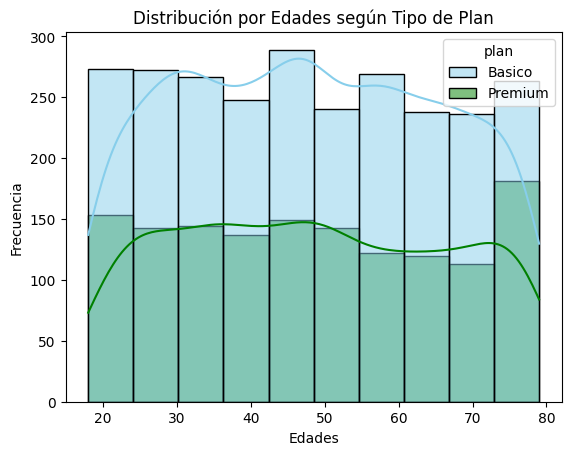

In [51]:

# Histograma para visualizar la edad (age)

sns.histplot(data=users, x="age", hue="plan",palette=['skyblue','green'], bins=10, kde=True)
plt.xlabel("Edades")
plt.ylabel("Frecuencia")
plt.title("Distribución por Edades según Tipo de Plan")
plt.show()



💡Insights: 
- La edad no parece ser un factor determinante en la elección del plan, ya que ambas distribuciones presentan patrones similares. Sin embargo, el plan Básico tiene mayor cantidad total de usuarios en todos los rangos de edad.

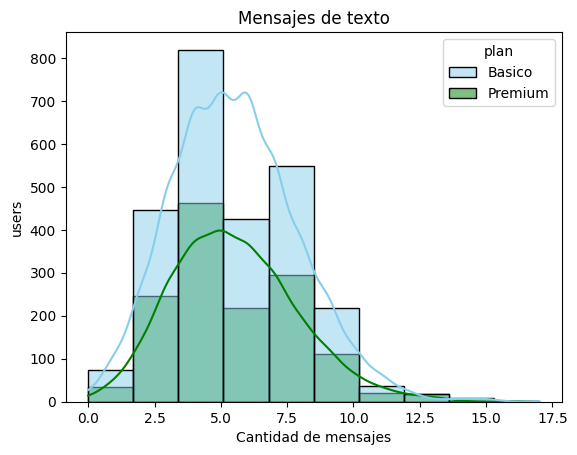

In [64]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", palette=['skyblue','green'], bins=10, kde=True)
plt.xlabel ("Cantidad de mensajes")
plt.ylabel ("users")
plt.title ("Mensajes de texto")
plt.show()


💡Insights: 
- La cantidad de mensajes enviados no muestra una diferencia clara entre los planes Básico y Premium. Ambas distribuciones presentan un comportamiento similar, aunque el plan Básico concentra un mayor número total de usuarios.

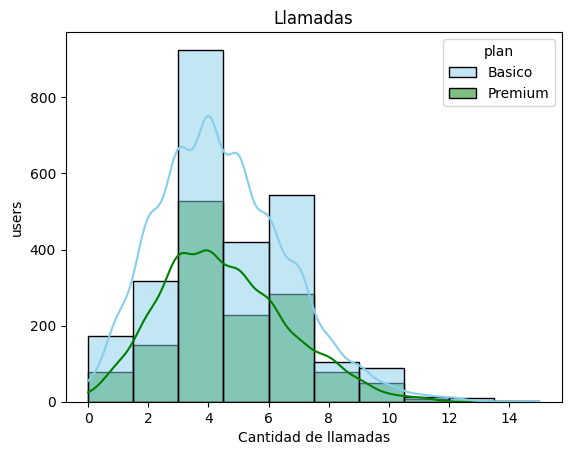

In [65]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", palette=['skyblue','green'], bins=10, kde=True)
plt.xlabel ("Cantidad de llamadas")
plt.ylabel ("users")
plt.title ("Llamadas")
plt.show(
)



💡Insights: 
- La cantidad de llamadas presenta un patrón similar entre los planes Básico y Premium. No se evidencia visualmente una diferencia significativa en el comportamiento de llamadas entre ambos grupos, aunque el plan Básico concentra un mayor número total de usuarios.

Text(0, 0.5, 'users')

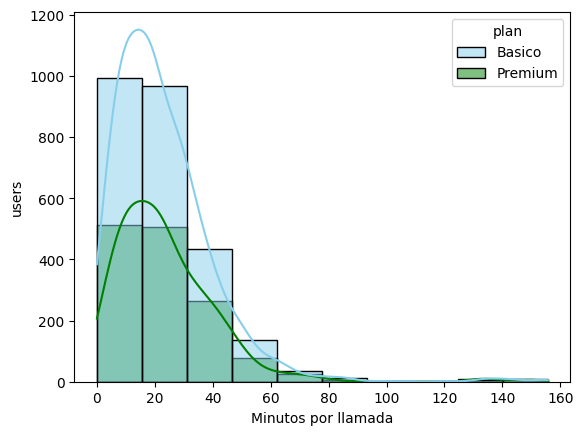

In [69]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", palette=['skyblue','green'], bins=10, kde=True)
plt.xlabel("Minutos por llamada")

plt.ylabel("users")


💡Insights: 
- "Muchos usuarios, llamadas cortas."

Comportamiento idéntico: No importa el plan (Básico o Premium), casi todos cuelgan antes de los 30 minutos.
El plan Básico tiene muchísimos más usuarios, pero su hábito de uso es igual al de los Premium.

-*Conclusión:* Las llamadas largas (más de 60 min) son raras excepciones en ambos grupos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

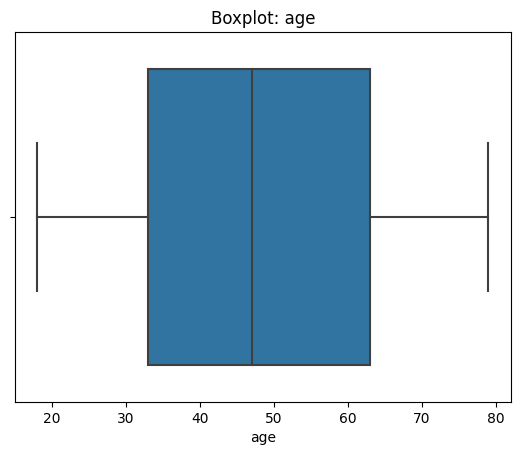

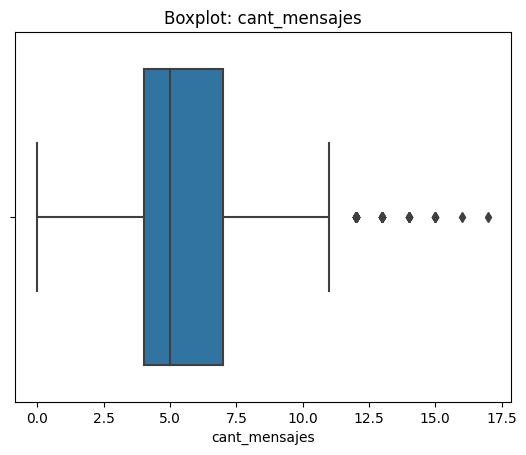

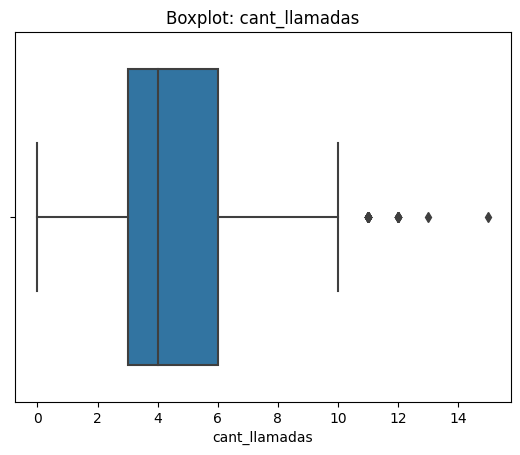

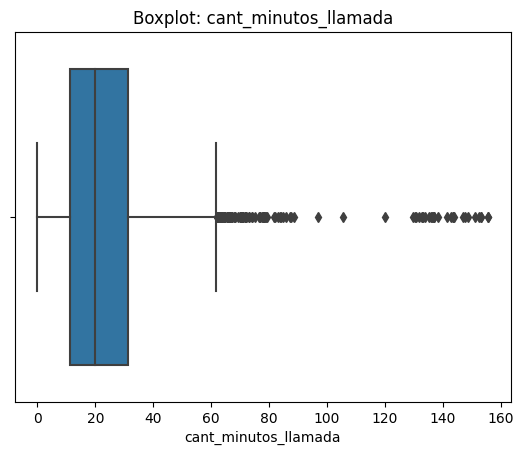

In [72]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])  # Sin bins
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: presenta outliers
- cant_llamadas: presenta outliers
- cant_minutos_llamada: presenta outliers

In [74]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes","cant_llamadas","cant_minutos_llamada"]

for col in columnas_limites:

#  Q1 (25%)  Q3 (75%)
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    
# IQR
    IQR = Q3 - Q1
    
# Definir límites 
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = user_profile[(user_profile[col] < limite_inferior) | (user_profile[col] > limite_superior)]
    
    print(f"Columna: {col}")
    print(f"Limite Superior: {limite_superior}")
    print(f"Cantidad de outliers: {len(outliers)}\n")


Columna: cant_mensajes
Limite Superior: 11.5
Cantidad de outliers: 46

Columna: cant_llamadas
Limite Superior: 10.5
Cantidad de outliers: 30

Columna: cant_minutos_llamada
Limite Superior: 61.8575
Cantidad de outliers: 109



In [75]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes:** mantener o no outliers, porqué?
  
*Mantener* Aunque el límite superior es 11.5, el valor máximo es 17. Son valores realistas para un servicio de mensajería; eliminarlos perdería información sobre usuarios activos sin corregir un error real.

- **cant_llamadas:** mantener o no outliers, porqué?
  
*Mantener* El límite es 10.5 y el máximo 15. Al igual que con los mensajes, realizar 15 llamadas en un periodo no es un error de sistema, sino un comportamiento de uso legítimo que debemos analizar.
  
- **cant_minutos_llamada:** mantener o no outliers, porqué?
  
*Filtrar / Capar*	El límite es 61.85, pero el máximo llega a 155.69 (más del doble). Estos valores extremos (109 casos) pueden sesgar significativamente la media y los modelos predictivos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [84]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [86]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_date_future_flag,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,0,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,0,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,0,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,0,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,0,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [81]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30, 
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [82]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_date_future_flag,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,0,7.0,3.0,23.70,Estándar,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,0,5.0,10.0,33.18,Estándar,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,0,5.0,2.0,10.74,Estándar,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,0,11.0,3.0,8.99,Estándar,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,0,4.0,3.0,8.01,Estándar,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

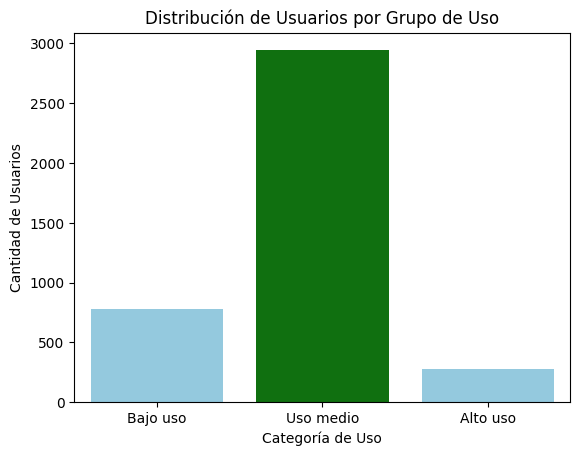

In [87]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue','green'], order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Categoría de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()


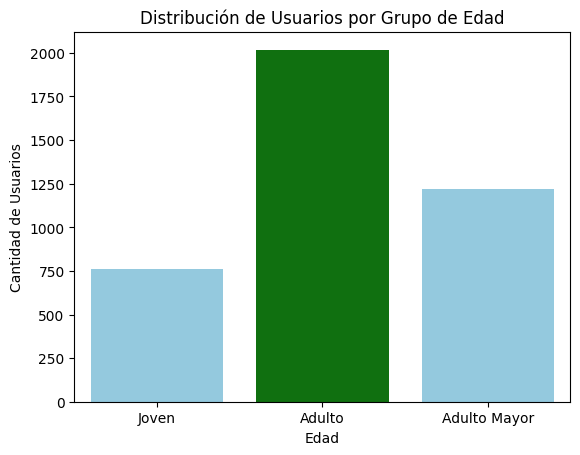

In [89]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue','green'], order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')



plt.show()




---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

*Columnas con valores faltantes:*
- city: 469 nulos (11 %) → revisar impacto en análisis.
- churn_date: 3534 nulos (88 %) → clientes activos.
- date: 39950 nulos (~99 %) → investigar registros sin fecha válida.
- duration: 22076 nulos (55 %) → llamadas no completadas.
- length: 17896 nulos (44 %) → llamadas no completadas.
  
*Tipos de datos a convertir a datetime:*
- reg_date, churn_date, date

*Valores inválidos / sentinels:*

- churn_date: NaN → cliente activo (3534 registros)
- city: NaN → ciudad no registrada (469 registros)
- date: NaN → registros sin fecha válida (39950 registros)
- duration y length: NaN → llamadas no completadas (22076 y 17896 registros)

🔍 **Segmentos por Edad**
- Adulto (principal): >2,000 usuarios (50 % de la base). Rango de edad laboral/productiva, representa el segmento mayoritario.
- Adulto Mayor (secundario): 1,200 usuarios. Indica retención sólida y mercado relevante para mayores de 50 años.
- Jóvenes: 750 usuarios. Menor participación; oportunidad de crecimiento o menor afinidad con el servicio.


📊 **Segmentos por Nivel de Uso**
- Uso Medio (principal): 3,000 usuarios. Gran mayoría realiza 5–10 llamadas/mensajes; base activa y estable.
- Bajo Uso: 750 usuarios. Usuarios ocasionales; no núcleo principal del negocio.
- Alto Uso (outliers): 300 usuarios. “Power Users”; pocos, pero con consumo muy alto.


➡️ Esto sugiere que ...


💡 **Recomendaciones**

- La mayoría de clientes son adultos en edad laboral y usan el servicio de forma moderada y constante.
- Existen oportunidades de crecimiento entre jóvenes y usuarios de bajo uso.
- Los clientes de alto uso, aunque pocos, son estratégicos para retención y fidelización.
  
- Incrementar engagement y adopción entre jóvenes y usuarios de bajo uso mediante campañas específicas, promociones o contenidos que conecten con sus necesidades.
- Fidelizar y maximizar el valor de los “Power Users” con beneficios exclusivos, programas de lealtad o atención personalizada.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: https://github.com/AnaMaBueno/sprint7-final-project.git